# 01 · Part 0 — 2022-vs-2026 contacts, non-redundancy & TCRen derivation

Reproduces `code_paper/1_Nonred_PDB_struct.Rmd` + `2_TCRen_derivation.Rmd` and extends it to a
2026 structure set. Both come from the HF dataset
[`isalgo/tcren_structures`](https://huggingface.co/datasets/isalgo/tcren_structures) in the
canonical orientation:

- **Native2022** — the original 2022 paper PDB set (the oracle reference);
- **Native2026** — the comprehensive 2026 TCR:pMHC set (peptide-preserving originals, validated).

For each set tcren annotates chains + TCR–peptide contacts, clusters for non-redundancy
(Damerau–Levenshtein of cdr3α+cdr3β+peptide, complete-linkage cut at h=6), and derives the
TCRen potential. We check that 2022 reproduces the published matrix and the legacy mir contact
**geometry**, then derive the larger **2026 TCRen** and compare it to the 2022 oracle. All new
results use only the HF structures + the tcren pipeline; the 2022 mir/R outputs in `data_legacy/`
are reference baselines only.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl
from tcren.paper import annotate_structure_set
from tcren.paper.helpers import _read_any
from tcren.potential import (derive_tcren, derive_tcren_loo, tcren as published_tcren,
                             alphabeta_ids, nonredundant_ids)

# alphabeta_ids / nonredundant_ids are the library versions of this notebook's former inline
# helpers (αβ-only pdb ids; one representative per complete-linkage cluster of summed
# Damerau–Levenshtein cdr3α+cdr3β+peptide distance, cut at h=6) — identical sets, single source.

Path('results_new').mkdir(exist_ok=True)
SETS = {'2022': '../data/Native2022', '2026': '../data/Native2026'}
for tag, p in SETS.items():
    print(f'{tag}: {len(list(Path(p).glob("*.pdb.gz")))} structures')

2022: 242 structures
2026: 374 structures


In [2]:
# Annotate both sets with tcren (TCR-peptide contacts + cdr3a/b+peptide markup). Cached.
data = {}
for tag, sdir in SETS.items():
    cp, mp = Path(f'results_new/contacts_{tag}.csv'), Path(f'results_new/markup_{tag}.csv')
    if cp.exists() and mp.exists():
        c, m = pl.read_csv(cp), pl.read_csv(mp)
    else:
        c, m = annotate_structure_set(sdir); c.write_csv(cp); m.write_csv(mp)
    data[tag] = (c, m)
    print(f'{tag}: {c.height} contacts over {c["pdb.id"].n_unique()} structures '
          f'({len(alphabeta_ids(c))} αβ)')

2022: 5294 contacts over 239 structures (238 αβ)
2026: 8062 contacts over 370 structures (369 αβ)


In [3]:
# VALIDATION: 2022 tcren contact GEOMETRY vs the legacy mir contacts (data_legacy oracle).
# Geometry = which TCR/peptide residues touch (residue index + aa). Chain-/region-LABEL diffs are
# TCR3D-adjudicated tcren-correct (γδ/βδ mislabelled by mir; CDR1-anchor Tyr). A handful of index
# diffs come from canonical-oriented structures that retain a TCR constant domain (the mir oracle
# is variable-domain-only) — exact V-only parity is covered by the regression test suite.
contacts22, _ = data['2022']
mir = _read_any('data_legacy/contact_maps_PDB.csv.gz')
GEOM = ['residue.index.from', 'residue.index.to', 'residue.aa.from', 'residue.aa.to']
shared = sorted(set(contacts22['pdb.id'].to_list()) & set(mir['pdb.id'].to_list()))

def rs(df, pid, keys):
    return set(map(tuple, df.filter(pl.col('pdb.id') == pid).select(keys).unique().rows()))

geom_ok = sum(rs(contacts22, p, GEOM) == rs(mir, p, GEOM) for p in shared)
print(f'2022 shared with mir: {len(shared)} | GEOMETRY exact: {geom_ok}/{len(shared)} '
      f'({100 * geom_ok / len(shared):.0f}%)')

2022 shared with mir: 235 | GEOMETRY exact: 226/235 (96%)


In [4]:
# Non-redundant αβ set for each (the input to TCRen derivation).
nonred = {}
for tag, (c, m) in data.items():
    ab = alphabeta_ids(c)
    keep = nonredundant_ids(m.filter(pl.col('pdb.id').is_in(ab)), t=6.0)
    nonred[tag] = keep
    print(f'{tag}: {len(ab)} αβ -> {len(keep)} non-redundant')

2022: 238 αβ -> 139 non-redundant
2026: 369 αβ -> 219 non-redundant


In [5]:
# Derive the 2022 and 2026 TCRen potentials; compare to the published 2022 matrix and to each other.
pub = published_tcren()
pots = {}
for tag, (c, _) in data.items():
    pot = derive_tcren(c, include=nonred[tag])
    pot.to_csv(f'results_new/TCRen_{tag}.csv')
    pots[tag] = pot
    j = pot.matrix.join(pub.matrix, on=['residue.aa.from', 'residue.aa.to'], suffix='_p')
    r = np.corrcoef(j['value'].to_numpy(), j['value_p'].to_numpy())[0, 1]
    print(f'TCRen {tag} (n={len(nonred[tag])}) vs published 2022 matrix: Pearson r = {r:.3f}')

# leave-one-out for the 2026 potential (used by the downstream benchmarks)
derive_tcren_loo(data['2026'][0], nonred['2026']).write_csv('results_new/TCRen_2026_LOO.csv')

j = pots['2022'].matrix.join(pots['2026'].matrix, on=['residue.aa.from', 'residue.aa.to'], suffix='_26')
r = np.corrcoef(j['value'].to_numpy(), j['value_26'].to_numpy())[0, 1]
print(f'\nTCRen 2022 vs 2026 (tcren-derived): Pearson r = {r:.3f} over {j.height} aa-pairs')
print('=> the 2026 potential is derived from more (validated) structures yet stays consistent '
      'with the published biophysics.')

TCRen 2022 (n=139) vs published 2022 matrix: Pearson r = 0.846
TCRen 2026 (n=219) vs published 2022 matrix: Pearson r = 0.918



TCRen 2022 vs 2026 (tcren-derived): Pearson r = 0.826 over 380 aa-pairs
=> the 2026 potential is derived from more (validated) structures yet stays consistent with the published biophysics.


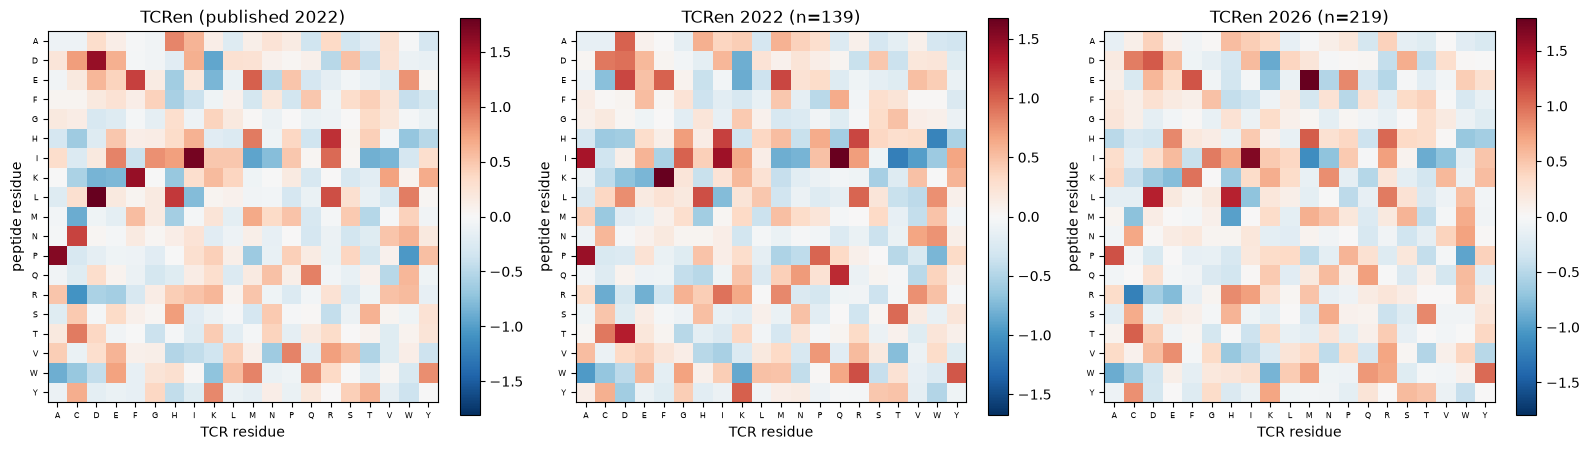

In [6]:
# Heatmaps: published 2022 vs tcren-derived 2022 vs tcren-derived 2026
%matplotlib inline
import matplotlib.pyplot as plt
from tcren.analysis import potential_matrix
panels = [(pub, 'TCRen (published 2022)'),
          (pots['2022'], f'TCRen 2022 (n={len(nonred["2022"])})'),
          (pots['2026'], f'TCRen 2026 (n={len(nonred["2026"])})')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (pot, title) in zip(axes, panels):
    m, fr, to = potential_matrix(pot); vlim = np.nanmax(np.abs(m))
    im = ax.imshow(m, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
    ax.set_xticks(range(len(to))); ax.set_xticklabels(to, fontsize=6)
    ax.set_yticks(range(len(fr))); ax.set_yticklabels(fr, fontsize=6)
    ax.set_title(title); ax.set_xlabel('TCR residue'); ax.set_ylabel('peptide residue')
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()